# Subsection 1

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

DATASET_ORDER = ["BCI2a", "EEGMMIDB", "Weibo2014", "Zhou2016"]
REGIME_ORDER = ["Intra-subject", "Cross-session", "Cross-subject"]

REPRESENTATION_ORDER = [
    "LogVar", "Line Length", "Bandpower", "Perm. Entropy",
    "LogCov", "Wavelet", "CSP", "RCSP", "Riemannian", "Fusion", "EEGNet"
]

In [29]:
def make_pseudo_results(seed=42):
    rng = np.random.default_rng(seed)
    rows = []

    for d, dataset in enumerate(DATASET_ORDER):
        for r, representation in enumerate(REPRESENTATION_ORDER):
            base = 0.58 + 0.015 * (r % 5) + rng.normal(0, 0.015)

            for regime in REGIME_ORDER:
                penalty = {
                    "Intra-subject": 0.00,
                    "Cross-session": 0.07,
                    "Cross-subject": 0.13
                }[regime]

                # Simulates subjects/configurations/classifiers/bands/etc.
                for _ in range(35):
                    ba = base - penalty + rng.normal(0, 0.045)
                    rows.append({
                        "dataset": dataset,
                        "representation": representation,
                        "regime": regime,
                        "balanced_accuracy": np.clip(ba, 0.25, 0.95)
                    })

    return pd.DataFrame(rows)

df_pseudo = make_pseudo_results()
df_pseudo.head()

,dataset,representation,regime,balanced_accuracy
0,BCI2a,LogVar,Intra-subject,0.537771
1,BCI2a,LogVar,Intra-subject,0.618341
2,BCI2a,LogVar,Intra-subject,0.626896
3,BCI2a,LogVar,Intra-subject,0.496774
4,BCI2a,LogVar,Intra-subject,0.525973


In [30]:
def plot_representation_generalization(
    df,
    dataset_order=None,
    representation_order=None,
    regime_order=None,
    metric="balanced_accuracy",
    figsize=(15, 12),
    fixed_ylim=False,
    save_path=None
):
    dataset_order = dataset_order or list(df["dataset"].dropna().unique())
    representation_order = representation_order or list(df["representation"].dropna().unique())
    regime_order = regime_order or list(df["regime"].dropna().unique())

    fig, axes = plt.subplots(
        len(dataset_order), 1,
        figsize=figsize,
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    if len(dataset_order) == 1:
        axes = [axes]

    x = np.arange(len(representation_order))
    width = 0.23
    offsets = np.linspace(-width, width, len(regime_order))
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for ax, dataset in zip(axes, dataset_order):
        ddf = df[df["dataset"] == dataset]
        means = {rep: {} for rep in representation_order}

        for j, regime in enumerate(regime_order):
            positions, values = [], []

            for i, representation in enumerate(representation_order):
                v = ddf[
                    (ddf["representation"] == representation) &
                    (ddf["regime"] == regime)
                ][metric].dropna().to_numpy()

                if len(v):
                    pos = x[i] + offsets[j]
                    positions.append(pos)
                    values.append(v)
                    means[representation][regime] = (pos, v.mean())

            if not values:
                continue

            color = colors[j % len(colors)]

            vp = ax.violinplot(
                values,
                positions=positions,
                widths=width * 0.9,
                showmeans=False,
                showmedians=True,
                showextrema=False
            )

            for body in vp["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor(color)
                body.set_alpha(0.55)

            vp["cmedians"].set_color(color)
            vp["cmedians"].set_linewidth(2)

        for representation in representation_order:
            pts = [
                means[representation][regime]
                for regime in regime_order
                if regime in means[representation]
            ]

            if len(pts) < 2:
                continue

            xs, ys = zip(*pts)
            ax.plot(xs, ys, linewidth=1.2, alpha=0.8, color="black", zorder=4)
            ax.scatter(xs, ys, s=28, color="black", zorder=5)

        ax.set_title(dataset, loc="left", fontweight="bold")
        ax.set_ylabel("Balanced Accuracy")
        ax.grid(axis="y", alpha=0.2)

        if fixed_ylim:
            ax.set_ylim(0, 1)
            ax.set_yticks(np.linspace(0, 1, 6))

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(representation_order, rotation=35, ha="right")

    handles = [
        Patch(
            facecolor=colors[i % len(colors)],
            alpha=0.55,
            label=regime
        )
        for i, regime in enumerate(regime_order)
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=len(regime_order),
        frameon=False
    )

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

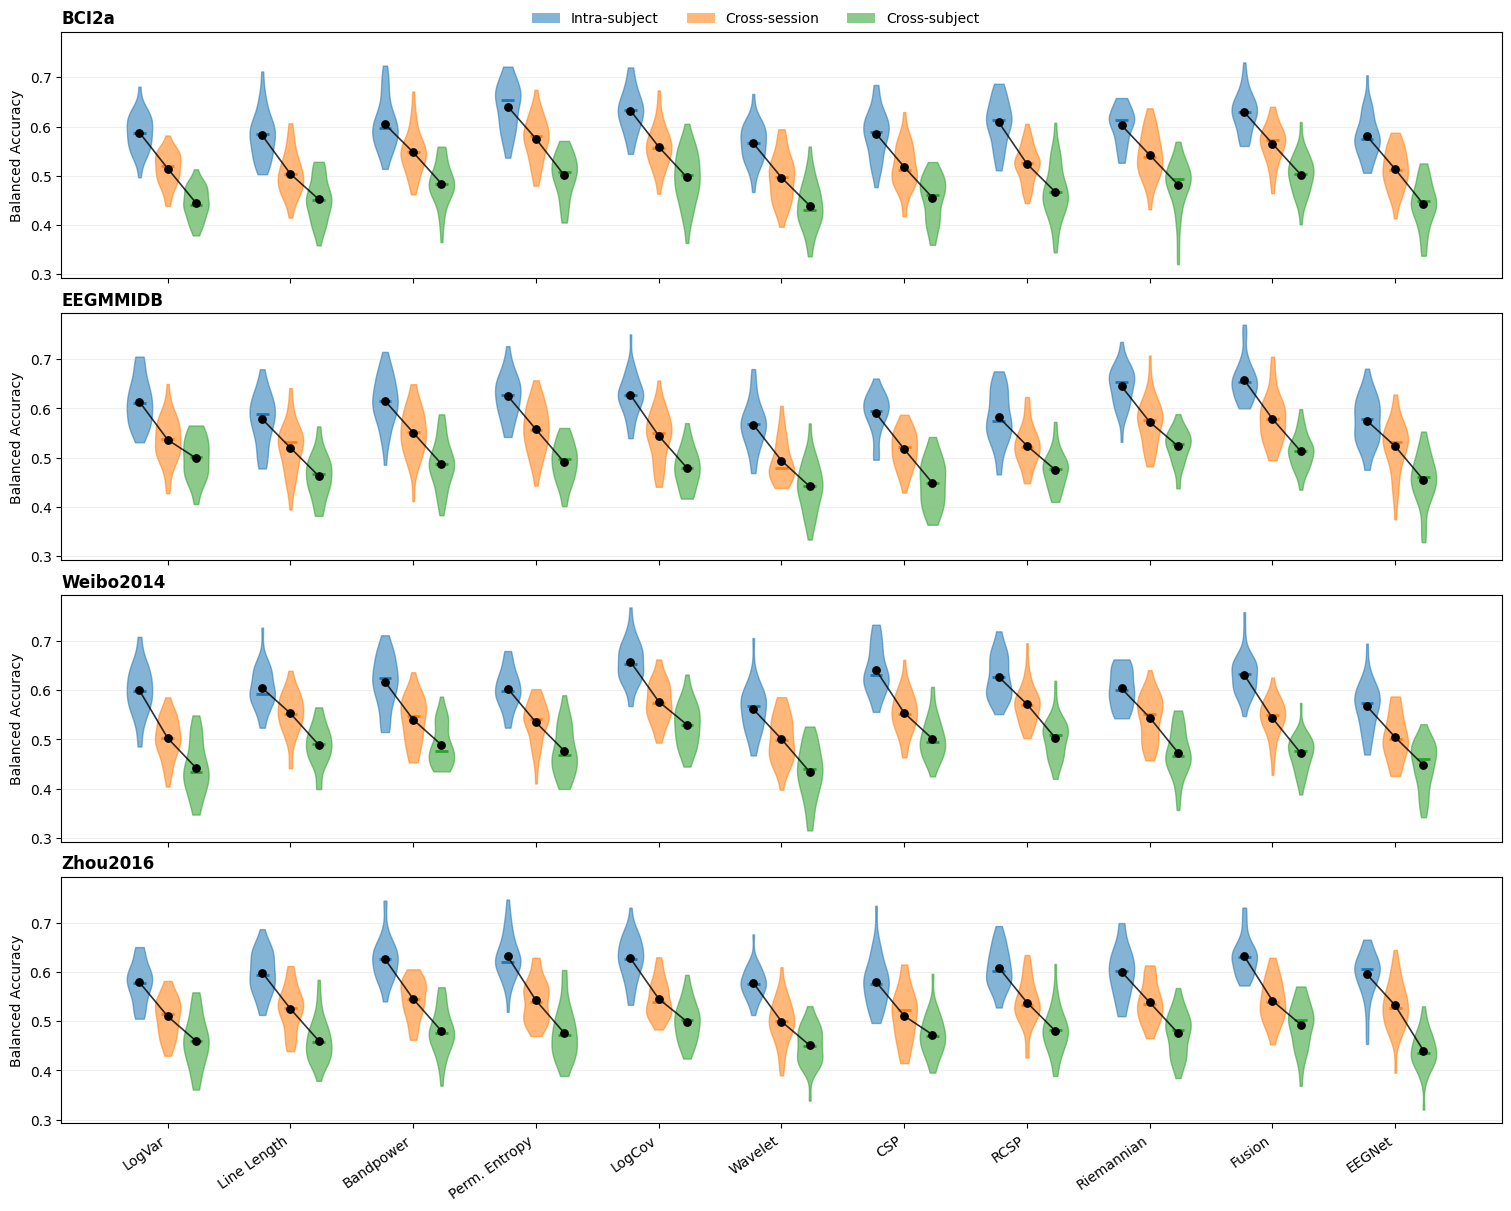

In [31]:
fig, axes = plot_representation_generalization(
    df_pseudo,
    dataset_order=DATASET_ORDER,
    representation_order=REPRESENTATION_ORDER,
    regime_order=REGIME_ORDER,
    save_path="representation_generalization.pdf",
    fixed_ylim=False
)

plt.show()

In [32]:
def select_best_configurations(
    df,
    metric="balanced_accuracy",
    config_cols=("representation", "configuration")
):
    config_cols = list(config_cols)

    # First average repetitions within each subject/configuration
    subject_scores = (
        df.groupby(
            ["dataset", "regime", "subject"] + config_cols,
            as_index=False
        )[metric]
        .mean()
    )

    # Then give every subject equal weight when selecting the best configuration
    config_scores = (
        subject_scores.groupby(
            ["dataset", "regime"] + config_cols,
            as_index=False
        )[metric]
        .mean()
    )

    idx = (
        config_scores.groupby(["dataset", "regime"])[metric]
        .idxmax()
    )

    best_configs = config_scores.loc[idx].reset_index(drop=True)

    # Keep only subject results belonging to the selected configuration
    best_subject_scores = subject_scores.merge(
        best_configs[["dataset", "regime"] + config_cols],
        on=["dataset", "regime"] + config_cols,
        how="inner"
    )

    return best_configs, best_subject_scores

In [33]:
best_configs, best_subject_scores = select_best_configurations(
    df_subject_pseudo,
    config_cols=["representation", "configuration"]
)

best_configs

,dataset,regime,representation,configuration,balanced_accuracy
0,BCI2a,Cross-session,Perm. Entropy,2,0.583011
1,BCI2a,Cross-subject,Perm. Entropy,1,0.526180
2,BCI2a,Intra-subject,Perm. Entropy,6,0.654326
3,EEGMMIDB,Cross-subject,EEGNet,10,0.524454
4,EEGMMIDB,Intra-subject,EEGNet,7,0.653885
5,Weibo2014,Cross-subject,Bandpower,0,0.530613
6,Weibo2014,Intra-subject,Bandpower,2,0.677185
7,Zhou2016,Cross-session,Perm. Entropy,7,0.582945
8,Zhou2016,Cross-subject,EEGNet,11,0.522906
9,Zhou2016,Intra-subject,Perm. Entropy,9,0.666038


In [34]:
def plot_best_configuration_subjects(
    best_subject_scores,
    best_configs,
    dataset_order=None,
    regime_order=None,
    metric="balanced_accuracy",
    config_cols=("representation", "configuration"),
    figsize=(18, 13),
    max_subject_labels=12,
    fixed_ylim=False,
    save_path=None
):
    config_cols = list(config_cols)
    dataset_order = dataset_order or list(best_subject_scores["dataset"].dropna().unique())
    regime_order = regime_order or list(best_subject_scores["regime"].dropna().unique())

    fig, axes = plt.subplots(
        len(dataset_order), len(regime_order),
        figsize=figsize,
        squeeze=False,
        sharey=True,
        constrained_layout=True
    )

    for row, dataset in enumerate(dataset_order):
        for col, regime in enumerate(regime_order):
            ax = axes[row, col]

            d = best_subject_scores[
                (best_subject_scores["dataset"] == dataset) &
                (best_subject_scores["regime"] == regime)
            ].copy()

            if d.empty:
                ax.text(0.5, 0.5, "Not available",
                        ha="center", va="center", transform=ax.transAxes)
                ax.set_xticks([])
                ax.set_frame_on(False)
                continue

            subjects = list(d["subject"])
            x = np.arange(len(subjects))
            y = d[metric].to_numpy()

            ax.plot(x, y, marker="o", linewidth=1.2, markersize=4)
            ax.axhline(y.mean(), linestyle="--", linewidth=1, alpha=0.7)

            step = max(1, int(np.ceil(len(subjects) / max_subject_labels)))
            ticks = np.arange(0, len(subjects), step)

            ax.set_xticks(ticks)
            ax.set_xticklabels(
                [subjects[i] for i in ticks],
                rotation=90,
                fontsize=8
            )

            cfg = best_configs[
                (best_configs["dataset"] == dataset) &
                (best_configs["regime"] == regime)
            ].iloc[0]

            config_text = ", ".join(
                f"{c}={cfg[c]}" for c in config_cols
            )

            if row == 0:
                ax.set_title(regime, fontweight="bold")

            ax.text(
                0.02, 0.96,
                config_text,
                transform=ax.transAxes,
                va="top",
                fontsize=8
            )

            if col == 0:
                ax.set_ylabel(f"{dataset}\nBalanced Accuracy")

            if row == len(dataset_order) - 1:
                ax.set_xlabel("Subject")

            ax.grid(axis="y", alpha=0.2)

            if fixed_ylim:
                ax.set_ylim(0, 1)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

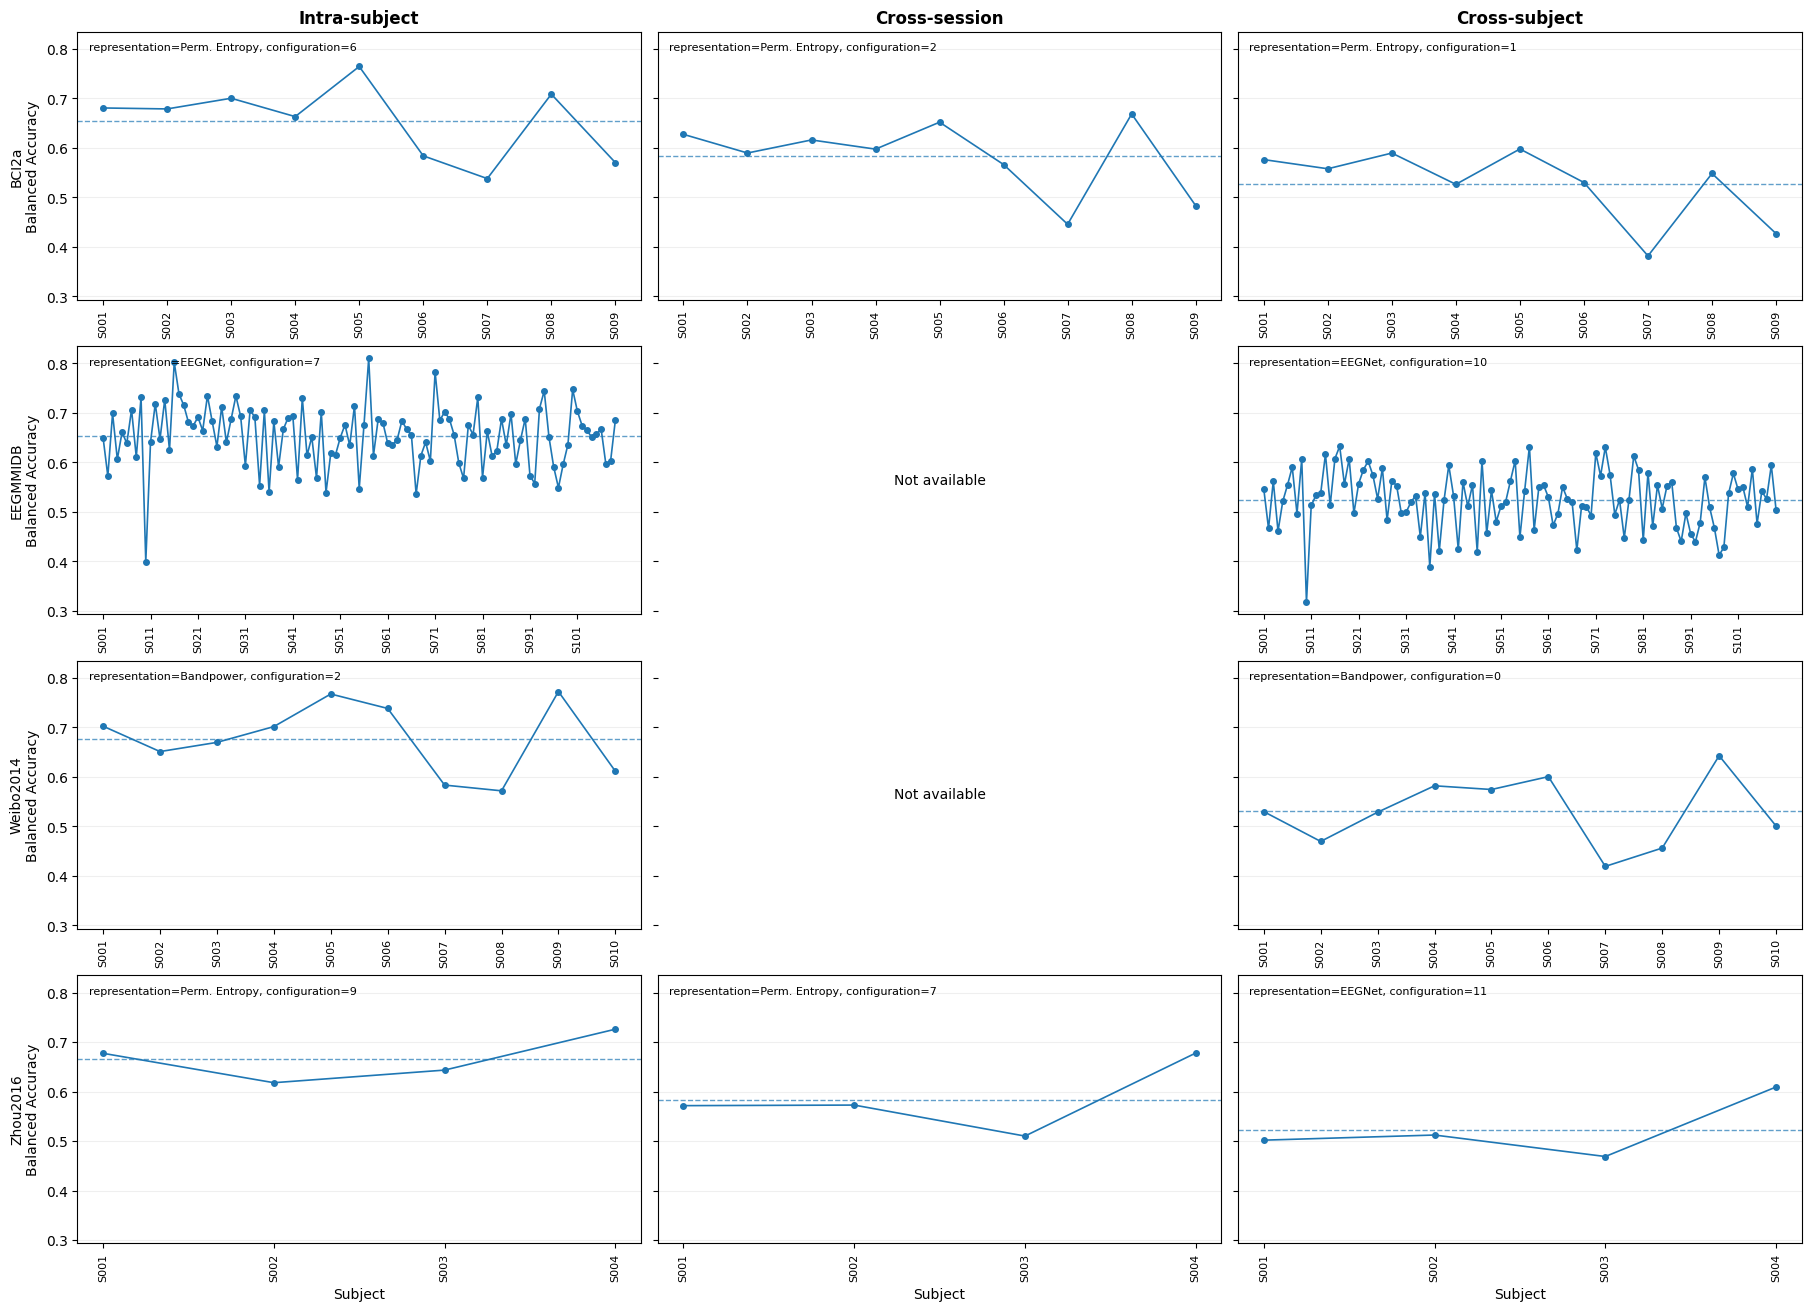

In [35]:
fig, axes = plot_best_configuration_subjects(
    best_subject_scores,
    best_configs,
    dataset_order=DATASET_ORDER,
    regime_order=REGIME_ORDER,
    config_cols=["representation", "configuration"],
    fixed_ylim=False,
    save_path="best_configuration_subjects.pdf"
)

plt.show()

# Subsection 2

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ORDER = ["BCI2a", "EEGMMIDB", "Weibo2014", "Zhou2016"]
REGIME_ORDER = ["Intra-subject", "Cross-session", "Cross-subject"]

REPRESENTATION_ORDER = [
    "LogVar", "Line Length", "Bandpower", "Perm. Entropy",
    "LogCov", "Wavelet", "CSP", "RCSP", "Riemannian", "Fusion", "EEGNet"
]

N_SUBJECTS = {
    "BCI2a": 9,
    "EEGMMIDB": 109,
    "Weibo2014": 10,
    "Zhou2016": 4
}

REGIME_AVAILABILITY = {
    "BCI2a": REGIME_ORDER,
    "EEGMMIDB": ["Intra-subject", "Cross-subject"],
    "Weibo2014": ["Intra-subject", "Cross-subject"],
    "Zhou2016": REGIME_ORDER
}

In [37]:
def make_pseudo_subject_results(seed=42, n_configs=12):
    rng = np.random.default_rng(seed)
    rows = []

    rep_effect = {
        rep: rng.normal(0, 0.025)
        for rep in REPRESENTATION_ORDER
    }

    for dataset in DATASET_ORDER:
        for subject in range(1, N_SUBJECTS[dataset] + 1):
            subject_effect = rng.normal(0, 0.05)

            # Makes the optimal representation genuinely vary somewhat by subject
            subject_rep_effect = {
                rep: rng.normal(0, 0.025)
                for rep in REPRESENTATION_ORDER
            }

            for regime in REGIME_AVAILABILITY[dataset]:
                penalty = {
                    "Intra-subject": 0.00,
                    "Cross-session": 0.07,
                    "Cross-subject": 0.13
                }[regime]

                for rep in REPRESENTATION_ORDER:
                    for config in range(n_configs):
                        ba = (
                            0.62
                            + rep_effect[rep]
                            + subject_effect
                            + subject_rep_effect[rep]
                            - penalty
                            + rng.normal(0, 0.025)
                        )

                        rows.append({
                            "dataset": dataset,
                            "subject": f"S{subject:03d}",
                            "regime": regime,
                            "representation": rep,
                            "configuration": config,
                            "balanced_accuracy": np.clip(ba, 0.25, 0.95)
                        })

    return pd.DataFrame(rows)

df_subject_pseudo = make_pseudo_subject_results()
df_subject_pseudo.head()

,dataset,subject,regime,representation,configuration,balanced_accuracy
0,BCI2a,S001,Intra-subject,LogVar,0,0.664295
1,BCI2a,S001,Intra-subject,LogVar,1,0.657450
2,BCI2a,S001,Intra-subject,LogVar,2,0.659355
3,BCI2a,S001,Intra-subject,LogVar,3,0.681466
4,BCI2a,S001,Intra-subject,LogVar,4,0.677294


In [38]:
def compute_subject_ranks(df, metric="balanced_accuracy"):
    summary = (
        df.groupby(
            ["dataset", "regime", "subject", "representation"],
            as_index=False
        )[metric]
        .mean()
    )

    summary["rank"] = (
        summary.groupby(["dataset", "regime", "subject"])[metric]
        .rank(method="average", ascending=False)
    )

    return summary

df_ranks = compute_subject_ranks(df_subject_pseudo)
df_ranks.head()

,dataset,regime,subject,representation,balanced_accuracy,rank
0,BCI2a,Cross-session,S001,Bandpower,0.630664,2.0
1,BCI2a,Cross-session,S001,CSP,0.604563,3.0
2,BCI2a,Cross-session,S001,EEGNet,0.638862,1.0
3,BCI2a,Cross-session,S001,Fusion,0.560235,9.0
4,BCI2a,Cross-session,S001,Line Length,0.588599,6.0


In [39]:
def plot_subject_rankings(
    rank_df,
    dataset_order=None,
    regime_order=None,
    representation_order=None,
    figsize=(18, 14),
    max_subject_labels=12,
    save_path=None
):
    dataset_order = dataset_order or list(rank_df["dataset"].dropna().unique())
    regime_order = regime_order or list(rank_df["regime"].dropna().unique())
    representation_order = representation_order or list(
        rank_df["representation"].dropna().unique()
    )

    n_rows = len(dataset_order)
    n_cols = len(regime_order)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=figsize,
        squeeze=False,
        constrained_layout=True
    )

    image = None

    for row, dataset in enumerate(dataset_order):
        for col, regime in enumerate(regime_order):
            ax = axes[row, col]

            d = rank_df[
                (rank_df["dataset"] == dataset) &
                (rank_df["regime"] == regime)
            ]

            if d.empty:
                ax.text(
                    0.5, 0.5, "Not available",
                    ha="center", va="center",
                    transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_frame_on(False)
                continue

            subjects = list(d["subject"].drop_duplicates())

            matrix = (
                d.pivot(
                    index="representation",
                    columns="subject",
                    values="rank"
                )
                .reindex(index=representation_order, columns=subjects)
            )

            image = ax.imshow(
                matrix.to_numpy(),
                aspect="auto",
                interpolation="nearest",
                vmin=1,
                vmax=len(representation_order),
                cmap="viridis_r"
            )

            # Subject labels: automatically thin for large datasets
            step = max(1, int(np.ceil(len(subjects) / max_subject_labels)))
            tick_idx = np.arange(0, len(subjects), step)

            ax.set_xticks(tick_idx)
            ax.set_xticklabels(
                [subjects[i] for i in tick_idx],
                rotation=90,
                fontsize=8
            )

            ax.set_yticks(np.arange(len(representation_order)))

            if col == 0:
                ax.set_yticklabels(representation_order)
                ax.set_ylabel(dataset, fontweight="bold")
            else:
                ax.set_yticklabels([])

            if row == 0:
                ax.set_title(regime, fontweight="bold")

            if row == n_rows - 1:
                ax.set_xlabel("Subject")

    if image is not None:
        cbar = fig.colorbar(
            image,
            ax=axes,
            shrink=0.75,
            pad=0.015
        )
        cbar.set_label("Representation rank (1 = best)")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

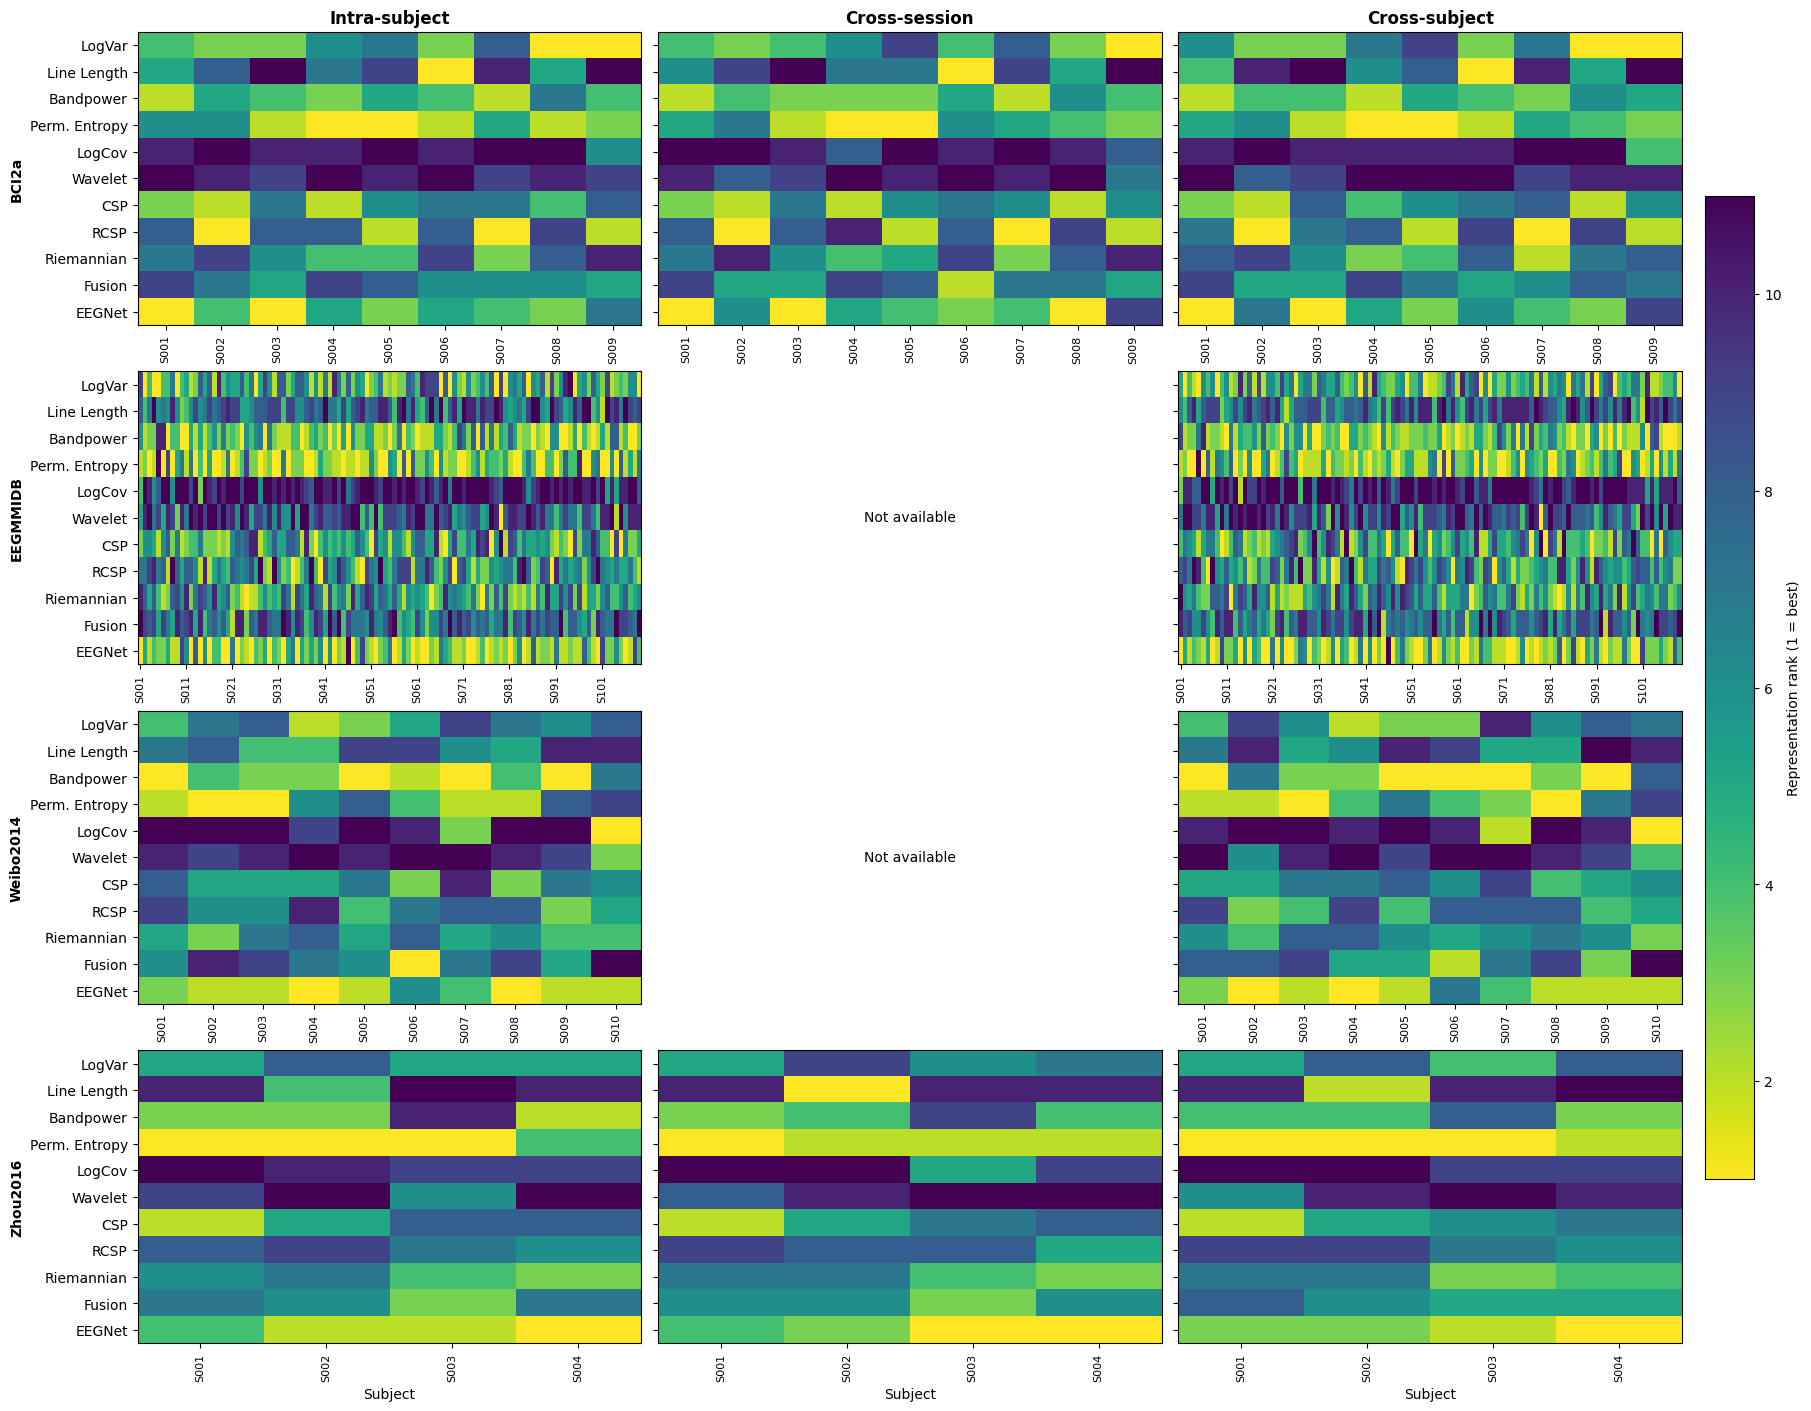

In [40]:
fig, axes = plot_subject_rankings(
    df_ranks,
    dataset_order=DATASET_ORDER,
    regime_order=REGIME_ORDER,
    representation_order=REPRESENTATION_ORDER,
    save_path="subject_representation_rankings.pdf"
)

plt.show()

# Subsection 3

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATASET_ORDER = ["BCI2a", "EEGMMIDB", "Weibo2014", "Zhou2016"]
REGIME_ORDER = ["Intra-subject", "Cross-session", "Cross-subject"]

REPRESENTATION_ORDER = [
    "LogVar", "Line Length", "Bandpower", "Perm. Entropy",
    "LogCov", "Wavelet", "CSP", "RCSP", "Riemannian", "Fusion", "EEGNet"
]

CLASSIFIER_ORDER = ["LDA", "LR", "SVM", "RF", "MLP"]
PREPROCESSING_ORDER = ["8–12 Hz", "13–30 Hz", "8–30 Hz", "Filter bank"]

N_SUBJECTS = {
    "BCI2a": 9,
    "EEGMMIDB": 109,
    "Weibo2014": 10,
    "Zhou2016": 4
}

REGIME_AVAILABILITY = {
    "BCI2a": REGIME_ORDER,
    "EEGMMIDB": ["Intra-subject", "Cross-subject"],
    "Weibo2014": ["Intra-subject", "Cross-subject"],
    "Zhou2016": REGIME_ORDER
}

In [42]:
def make_pseudo_configuration_results(seed=42):
    rng = np.random.default_rng(seed)
    rows = []

    rep_effect = {r: rng.normal(0, 0.035) for r in REPRESENTATION_ORDER}

    classifier_effect = {
        r: {m: rng.normal(0, 0.018) for m in CLASSIFIER_ORDER}
        for r in REPRESENTATION_ORDER
    }

    preprocessing_effect = {
        r: {p: rng.normal(0, 0.022) for p in PREPROCESSING_ORDER}
        for r in REPRESENTATION_ORDER
    }

    for dataset in DATASET_ORDER:
        for subject in range(1, N_SUBJECTS[dataset] + 1):
            subject_effect = rng.normal(0, 0.045)

            for regime in REGIME_AVAILABILITY[dataset]:
                penalty = {
                    "Intra-subject": 0.00,
                    "Cross-session": 0.07,
                    "Cross-subject": 0.13
                }[regime]

                for rep in REPRESENTATION_ORDER:
                    for classifier in CLASSIFIER_ORDER:
                        for preprocessing in PREPROCESSING_ORDER:
                            ba = (
                                0.62
                                + rep_effect[rep]
                                + classifier_effect[rep][classifier]
                                + preprocessing_effect[rep][preprocessing]
                                + subject_effect
                                - penalty
                                + rng.normal(0, 0.018)
                            )

                            rows.append({
                                "dataset": dataset,
                                "subject": f"S{subject:03d}",
                                "regime": regime,
                                "representation": rep,
                                "classifier": classifier,
                                "preprocessing": preprocessing,
                                "balanced_accuracy": np.clip(ba, 0.25, 0.95)
                            })

    return pd.DataFrame(rows)

df_config_pseudo = make_pseudo_configuration_results()
df_config_pseudo.head()

,dataset,subject,regime,representation,classifier,preprocessing,balanced_accuracy
0,BCI2a,S001,Intra-subject,LogVar,LDA,8–12 Hz,0.660822
1,BCI2a,S001,Intra-subject,LogVar,LDA,13–30 Hz,0.643348
2,BCI2a,S001,Intra-subject,LogVar,LDA,8–30 Hz,0.657061
3,BCI2a,S001,Intra-subject,LogVar,LDA,Filter bank,0.661304
4,BCI2a,S001,Intra-subject,LogVar,LR,8–12 Hz,0.634200


In [43]:
def compute_configuration_effects(
    df,
    factor,
    metric="balanced_accuracy"
):
    keys = ["dataset", "regime", "representation", factor]

    subject_mean = (
        df.groupby(keys + ["subject"], as_index=False)[metric]
        .mean()
    )

    config_mean = (
        subject_mean.groupby(keys, as_index=False)[metric]
        .mean()
    )

    representation_mean = (
        config_mean.groupby(
            ["dataset", "regime", "representation"],
            as_index=False
        )[metric]
        .mean()
        .rename(columns={metric: "representation_mean"})
    )

    effects = config_mean.merge(
        representation_mean,
        on=["dataset", "regime", "representation"]
    )

    effects["delta_ba"] = (
        effects[metric] - effects["representation_mean"]
    )

    return effects

In [44]:
def plot_configuration_robustness(
    effects,
    factor,
    factor_order,
    dataset_order=None,
    regime_order=None,
    representation_order=None,
    value_col="delta_ba",
    figsize=(17, 15),
    annotate=True,
    shared_scale=True,
    save_path=None
):
    dataset_order = dataset_order or list(effects["dataset"].dropna().unique())
    regime_order = regime_order or list(effects["regime"].dropna().unique())
    representation_order = representation_order or list(
        effects["representation"].dropna().unique()
    )

    fig, axes = plt.subplots(
        len(dataset_order),
        len(regime_order),
        figsize=figsize,
        squeeze=False,
        constrained_layout=True
    )

    vmax = np.nanmax(np.abs(effects[value_col])) if shared_scale else None
    vmax = max(vmax, 1e-6) if shared_scale else None

    image = None

    for row, dataset in enumerate(dataset_order):
        for col, regime in enumerate(regime_order):
            ax = axes[row, col]

            d = effects[
                (effects["dataset"] == dataset) &
                (effects["regime"] == regime)
            ]

            if d.empty:
                ax.text(
                    0.5, 0.5, "Not available",
                    ha="center", va="center",
                    transform=ax.transAxes
                )
                ax.set_xticks([])
                ax.set_yticks([])
                ax.set_frame_on(False)
                continue

            matrix = (
                d.pivot(
                    index="representation",
                    columns=factor,
                    values=value_col
                )
                .reindex(
                    index=representation_order,
                    columns=factor_order
                )
            )

            local_vmax = (
                vmax if shared_scale
                else max(np.nanmax(np.abs(matrix.to_numpy())), 1e-6)
            )

            image = ax.imshow(
                matrix.to_numpy(),
                aspect="auto",
                interpolation="nearest",
                cmap="coolwarm",
                vmin=-local_vmax,
                vmax=local_vmax
            )

            ax.set_xticks(np.arange(len(factor_order)))
            ax.set_xticklabels(
                factor_order,
                rotation=35,
                ha="right",
                fontsize=8
            )

            ax.set_yticks(np.arange(len(representation_order)))

            if col == 0:
                ax.set_yticklabels(representation_order, fontsize=8)
                ax.set_ylabel(dataset, fontweight="bold")
            else:
                ax.set_yticklabels([])

            if row == 0:
                ax.set_title(regime, fontweight="bold")

            if annotate:
                values = matrix.to_numpy()

                for i in range(values.shape[0]):
                    for j in range(values.shape[1]):
                        value = values[i, j]

                        if np.isfinite(value):
                            ax.text(
                                j, i,
                                f"{value:+.3f}",
                                ha="center",
                                va="center",
                                fontsize=6.5
                            )

    if image is not None:
        cbar = fig.colorbar(
            image,
            ax=axes,
            shrink=0.8,
            pad=0.015
        )
        cbar.set_label(r"$\Delta$ Balanced Accuracy")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    return fig, axes

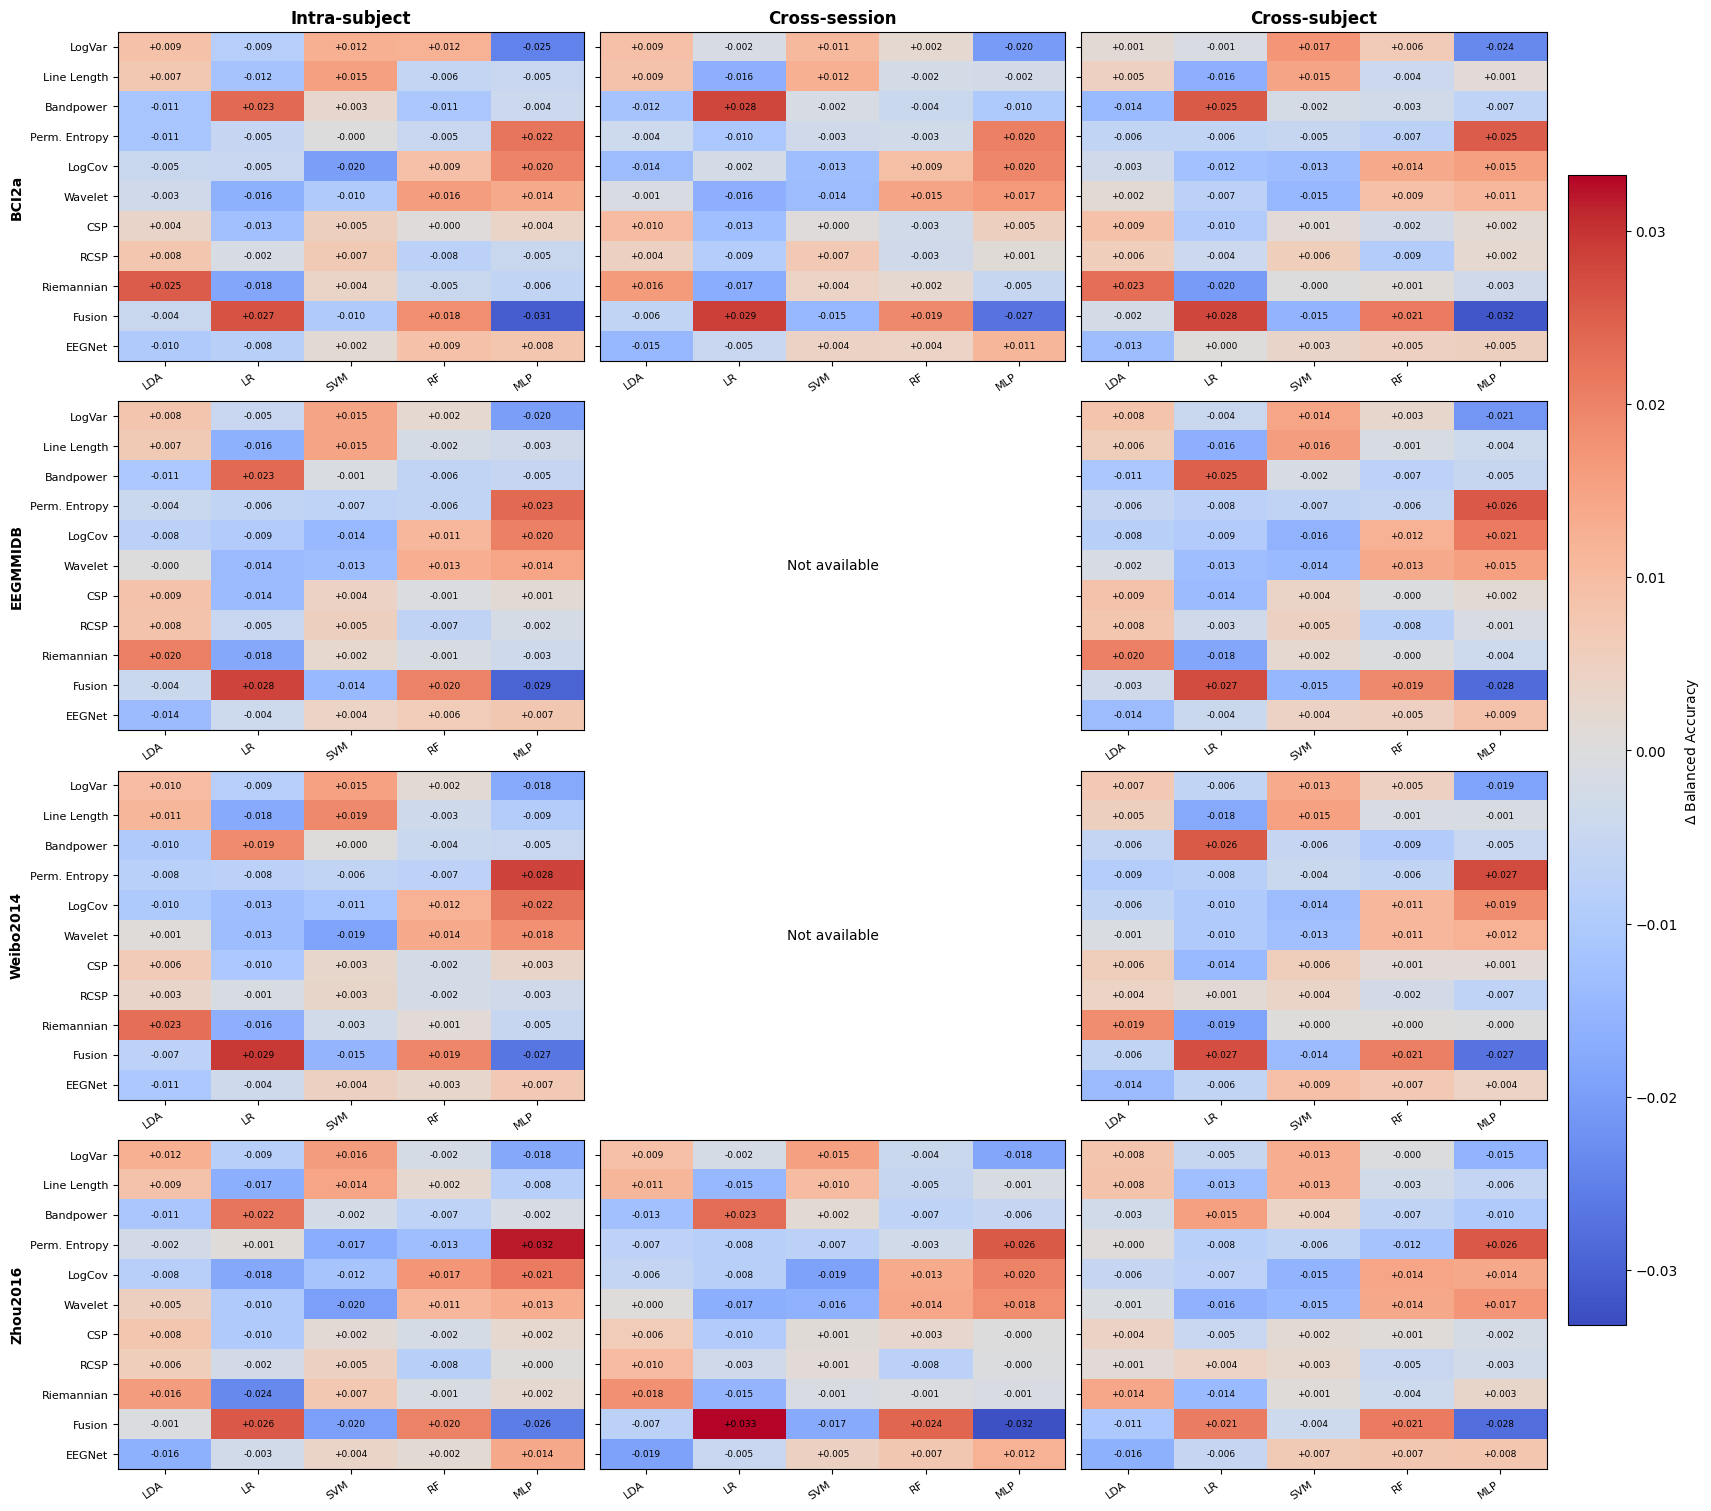

In [45]:
classifier_effects = compute_configuration_effects(
    df_config_pseudo,
    factor="classifier"
)

fig, axes = plot_configuration_robustness(
    classifier_effects,
    factor="classifier",
    factor_order=CLASSIFIER_ORDER,
    dataset_order=DATASET_ORDER,
    regime_order=REGIME_ORDER,
    representation_order=REPRESENTATION_ORDER,
    save_path="classifier_robustness.pdf"
)

plt.show()

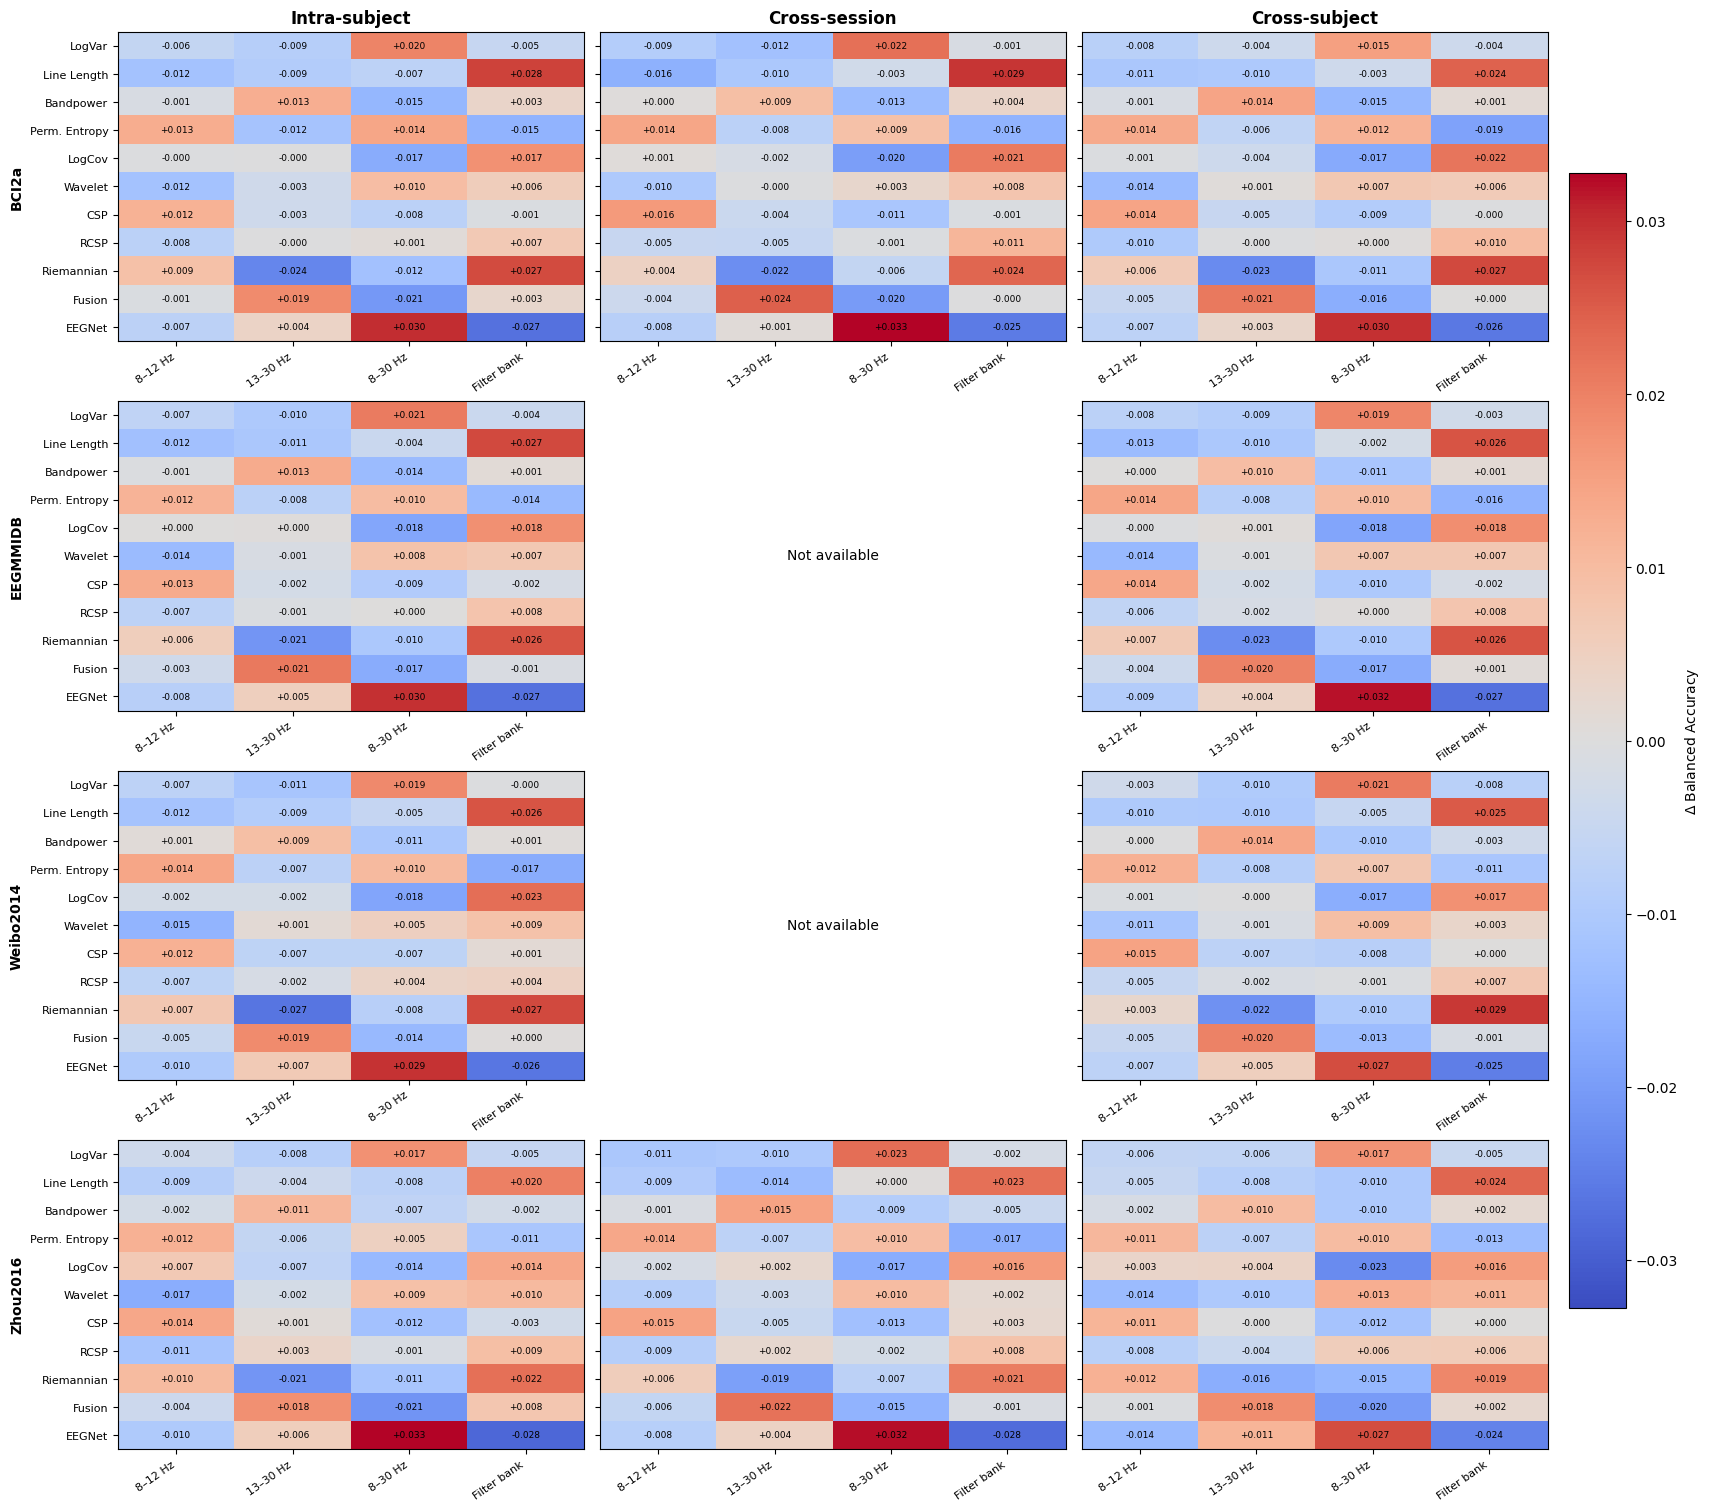

In [46]:
preprocessing_effects = compute_configuration_effects(
    df_config_pseudo,
    factor="preprocessing"
)

fig, axes = plot_configuration_robustness(
    preprocessing_effects,
    factor="preprocessing",
    factor_order=PREPROCESSING_ORDER,
    dataset_order=DATASET_ORDER,
    regime_order=REGIME_ORDER,
    representation_order=REPRESENTATION_ORDER,
    save_path="preprocessing_robustness.pdf"
)

plt.show()